<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E7%89%B9%E5%BE%B5%E7%AF%A9%E9%81%B8Y2_%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%AC%E9%96%8B%E7%99%BC%E4%B8%AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2025-07-10 12:09:52--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 172.217.0.78, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|172.217.0.78|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-07-10 12:09:52--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.0.65, 2607:f8b0:4025:810::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.0.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  55.1MB/s    in 0.4s    

2025-07-10 12:09:54 (55.1 MB/s) - 

#載入資料

In [59]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,5.540932,6.8,67.034424,151.208024,9.623605,8.619934,8.619934,20.605973,0,17.456094,...,876.984866,845.297084,845.703201,876.997523,59.200001,15,0.969941,0.871410,2230.093232,2.223152
2024-01-01 00:05:00,5.533478,6.8,66.662524,150.811453,9.616252,8.147002,8.147002,20.18102,0,17.449118,...,875.326466,846.587071,844.10285,877.38106,59.200001,15,0.969979,0.877787,2220.527929,2.220789
2024-01-01 00:10:00,5.526025,6.8,64.320729,151.708113,9.608899,8.247992,8.247992,20.200619,0,17.442142,...,875.675699,845.374599,843.500123,877.8976,59.200001,15,0.971249,0.871768,2237.129686,2.217612
2024-01-01 00:15:00,5.518571,6.801543,64.840762,151.283528,9.600898,7.60582,7.60582,20.220218,0,17.571883,...,875.435828,845.10045,842.910508,874.888616,59.200001,15,0.970896,0.882700,2227.895501,2.214444
2024-01-01 00:20:00,5.511117,6.819977,64.390831,150.994896,9.581994,6.110485,6.110485,20.549012,0,17.339679,...,875.2454,846.058978,844.200021,878.41671,59.200001,15,0.970878,0.905103,2211.052236,2.211285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,5.140339,114.166438,209.520746,9.360355,13.105704,13.105704,12.795748,11.854892,12.8422,...,916.635699,889.885541,906.016252,870.865216,100,26.103367,0.945172,0.885205,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,5.166336,106.669841,208.177318,9.280099,9.903673,9.903673,12.797045,11.862273,12.823741,...,914.06561,889.042164,904.255862,869.007829,100,26.093265,0.948517,0.907156,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,5.225976,104.663595,211.564232,9.359701,9.345572,9.345572,12.798342,11.880556,12.842696,...,913.978871,890.439554,903.442876,867.71297,100,26.1,0.949882,0.910708,2088.339754,3.928170


# 根據規則篩選資料

In [60]:
coal_low = df[df["MLUT4_FIQ-2BTCF"] < 20]
sox = df["MLUT4_AT-240"]
constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
constant_sox = df.loc[constant_sox_indices]
common_index = coal_low.index.union(constant_sox.index)
select_df = df.loc[~df.index.isin(common_index), :]

# 定義X,Y

In [61]:
# 1. 拷貝原始資料
XY = select_df.copy()

# 2. 將 inf / -inf 轉為 NaN
XY = XY.replace([np.inf, -np.inf], np.nan)

# 3. 移除含有 NaN 的列
XY = XY.dropna()

# 4. 拆出 X 和 Y
X = XY.drop(columns='DeSOx_2nd')
Y = XY['DeSOx_2nd']

# 5. 顯示
display(X)
display(Y)


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252E,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-08-23 17:00:00,11.019652,8.830332,32.441800,185.815216,13.077956,13.249987,13.255087,10.950182,0.000000,10.950274,...,886.711796,894.027277,835.059578,826.004638,662.610195,99.718430,16.113468,0.967759,1006.225732,3.500219
2024-08-23 17:05:00,10.857952,8.613570,37.254989,185.600042,12.926356,15.443319,15.436525,11.442738,0.000000,11.419443,...,890.011291,900.298364,838.948730,832.497588,661.046806,99.743865,16.103367,0.963406,1018.055063,3.424514
2024-08-23 17:10:00,10.308472,8.112952,46.869535,189.851207,12.444639,20.473462,20.473462,11.924871,0.000000,12.029547,...,897.983184,908.308105,848.087966,843.160346,659.583168,99.737038,16.100000,0.956381,1074.529010,5.667321
2024-08-23 17:15:00,10.010508,8.105663,42.471621,199.006285,12.351482,18.507946,18.513021,13.128604,0.000000,13.089082,...,903.316367,913.088073,857.724034,851.861139,658.900024,99.742083,16.100000,0.963338,1158.470498,6.977209
2024-08-23 17:20:00,9.484923,7.705050,46.277975,199.097859,11.906957,20.046827,20.046827,13.757199,0.000000,13.767773,...,907.493642,917.773098,864.805887,862.657110,658.105400,99.743899,16.105050,0.962827,1244.919060,6.731699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,5.140339,114.166438,209.520746,9.360355,13.105704,13.105704,12.795748,11.854892,12.842200,...,913.593762,916.635699,889.885541,906.016252,870.865216,100.000000,26.103367,0.945172,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,5.166336,106.669841,208.177318,9.280099,9.903673,9.903673,12.797045,11.862273,12.823741,...,911.424740,914.065610,889.042164,904.255862,869.007829,100.000000,26.093265,0.948517,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,5.225976,104.663595,211.564232,9.359701,9.345572,9.345572,12.798342,11.880556,12.842696,...,911.234664,913.978871,890.439554,903.442876,867.712970,100.000000,26.100000,0.949882,2088.339754,3.928170


,DeSOx_2nd
datetime,
2024-08-23 17:00:00,0.591577
2024-08-23 17:05:00,0.585470
2024-08-23 17:10:00,0.563182
2024-08-23 17:15:00,0.564228
2024-08-23 17:20:00,0.566817
...,...
2024-09-15 23:35:00,0.885205
2024-09-15 23:40:00,0.907156
2024-09-15 23:45:00,0.910708


In [62]:
x_col = X.columns.tolist()
y_col = Y.name

In [63]:
X.isnull().sum().sum()

np.int64(0)

# 特徵篩選

In [64]:
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
import numpy as np
from tqdm import tqdm

ss = StandardScaler()
皮爾森相關係數 = {}
for i in tqdm(x_col):
  try:
    # 刪除離群值
    data = XY.copy()
    # 轉換
    data[:] = ss.fit_transform(data[:])
    # 皮爾森相關係數
    r, p = pearsonr(data[i],data['DeSOx_2nd'])
    print(f"皮爾森相關係數 r = {r}")
    print(f"p-value = {p}")
    皮爾森相關係數[i] = r
  except:
    pass

 14%|█▎        | 8/59 [00:00<00:01, 48.31it/s]

皮爾森相關係數 r = -0.06167817820264873
p-value = 6.553885894731789e-07
皮爾森相關係數 r = -0.2972858081398996
p-value = 1.2005714314769305e-132
皮爾森相關係數 r = 0.49518239907462513
p-value = 0.0
皮爾森相關係數 r = 0.08359406611609108
p-value = 1.5096221510729057e-11
皮爾森相關係數 r = -0.1884410948538094
p-value = 5.612055154654624e-53
皮爾森相關係數 r = -0.4117206525775373
p-value = 3.417260354769916e-264
皮爾森相關係數 r = -0.41174577548657054
p-value = 3.151623065963869e-264
皮爾森相關係數 r = 0.15934299537774269
p-value = 3.432239732995099e-38
皮爾森相關係數 r = -0.1177266873897835
p-value = 1.7597452037526787e-21
皮爾森相關係數 r = 0.3389370381797139
p-value = 2.733857082803493e-174
皮爾森相關係數 r = 0.1308242631132197
p-value = 3.4601254141970566e-26
皮爾森相關係數 r = 0.20112603636318793
p-value = 3.0177491005464997e-60


 47%|████▋     | 28/59 [00:00<00:00, 82.52it/s]

皮爾森相關係數 r = 0.19705903598309982
p-value = 7.339226542356857e-58
皮爾森相關係數 r = 0.10181024321304762
p-value = 1.9647780834911505e-16
皮爾森相關係數 r = 0.0462499782097585
p-value = 0.0001927385957209564
皮爾森相關係數 r = nan
p-value = nan
皮爾森相關係數 r = 0.13446405118216007
p-value = 1.3860362564791712e-27
皮爾森相關係數 r = 0.2584625499823777
p-value = 1.3062185286097315e-99
皮爾森相關係數 r = 0.10018712724901684
p-value = 5.848684840666359e-16
皮爾森相關係數 r = 0.28263752525085206
p-value = 1.502470397785256e-119
皮爾森相關係數 r = 0.28335459994306317
p-value = 3.578920266329667e-120
皮爾森相關係數 r = 0.2036817781345104
p-value = 8.98381661444715e-62
皮爾森相關係數 r = -0.01869957492328113
p-value = 0.13187382760592828
皮爾森相關係數 r = -0.00640215923832136
p-value = 0.6059757550684967
皮爾森相關係數 r = 0.03148729512251831
p-value = 0.011162961519834907
皮爾森相關係數 r = 0.20816492626178135
p-value = 1.6824152361707175e-64
皮爾森相關係數 r = 0.1376331832646364
p-value = 7.82119856435289e-29
皮爾森相關係數 r = -0.017940270647633497
p-value = 0.1483003262790804
皮爾森相關係數 r = 0.2

 85%|████████▍ | 50/59 [00:00<00:00, 95.26it/s]

皮爾森相關係數 r = -0.008020916888290104
p-value = 0.5181145948499954
皮爾森相關係數 r = -0.02775911916181395
p-value = 0.025287713657686613
皮爾森相關係數 r = 0.20360410874464013
p-value = 1.0003437399611135e-61
皮爾森相關係數 r = -0.12330203759802973
p-value = 2.0110194816805882e-23
皮爾森相關係數 r = -0.11454894134023605
p-value = 2.0503980922076042e-20
皮爾森相關係數 r = 0.06095463731484678
p-value = 8.847628645229566e-07
皮爾森相關係數 r = 0.16546255962158726
p-value = 4.379324991227534e-41
皮爾森相關係數 r = 0.2722592830869506
p-value = 9.74304047437947e-111
皮爾森相關係數 r = 0.14714313210888275
p-value = 9.284733176708258e-33
皮爾森相關係數 r = 0.31967177386190454
p-value = 3.3656084900945866e-154
皮爾森相關係數 r = 0.13110194557632587
p-value = 2.71559753461189e-26
皮爾森相關係數 r = 0.011404729738053808
p-value = 0.35814411589963197
皮爾森相關係數 r = -0.016367087681681144
p-value = 0.18724198529362843
皮爾森相關係數 r = -0.06977368884392529
p-value = 1.8176706751868994e-08
皮爾森相關係數 r = 0.05238690857359177
p-value = 2.4031818075720028e-05
皮爾森相關係數 r = 0.11740850265577417
p-

100%|██████████| 59/59 [00:00<00:00, 87.35it/s]

皮爾森相關係數 r = 0.04300453287095504
p-value = 0.0005273363153872133
皮爾森相關係數 r = -0.026684544504126724
p-value = 0.031527341572973204
皮爾森相關係數 r = -0.45163629351304607
p-value = 1e-323
皮爾森相關係數 r = 0.08951549051937913
p-value = 4.946514364731131e-13
皮爾森相關係數 r = -0.12613390895206833
p-value = 1.9152289162168935e-24


In [65]:
import pandas as pd

res_皮爾森 = pd.DataFrame(皮爾森相關係數,index=[0]).T.sort_values(by=0,ascending=False)
res_皮爾森 = res_皮爾森.abs()
res_皮爾森 = res_皮爾森.sort_values(by=0,ascending=False)
res_皮爾森 = res_皮爾森[~res_皮爾森.index.to_series().str.contains('DeSOx_2nd')]
res_皮爾森.head(20)

,0
MLUT4_AIC-232B,0.495182
DeSOx_1st,0.451636
MLUT4_AT-240A,0.411746
MLUT4_AT-240,0.411721
MLUT4_FIC-231C,0.338937
MLUT4_TE-252G,0.325238
MLUT4_TE-251G,0.319672
MLUT4_AIA792101B,0.297286
MLUT4_FT-957,0.283355
MLUT4_FT-956,0.282638


In [66]:
res_皮爾森 = res_皮爾森.dropna(subset=[0])  # 移除有 NaN 的 row（如果你願意）
res_皮爾森['score'] = res_皮爾森[0].rank(method='min', ascending=True).astype(int)
res_皮爾森

,0,score
MLUT4_AIC-232B,0.495182,58
DeSOx_1st,0.451636,57
MLUT4_AT-240A,0.411746,56
MLUT4_AT-240,0.411721,55
MLUT4_FIC-231C,0.338937,54
MLUT4_TE-252G,0.325238,53
MLUT4_TE-251G,0.319672,52
MLUT4_AIA792101B,0.297286,51
MLUT4_FT-957,0.283355,50
MLUT4_FT-956,0.282638,49


In [67]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_scores(df):
    X = df.select_dtypes(include=[float, int]).dropna()
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    # 重要性計算
    vif_data["1/VIF"] = 1 / vif_data["VIF"]
    max_vif = vif_data["VIF"].max()
    min_vif = vif_data["VIF"].min()
    vif_data["max-VIF"] = max_vif - vif_data["VIF"]
    vif_data["normalized_score"] = (vif_data["max-VIF"]) / (max_vif - min_vif)
    return vif_data.sort_values("normalized_score", ascending=False)
res_VIF = compute_vif_scores(XY[x_col].sample(1000)).fillna(0)
res_VIF['score'] = res_VIF['normalized_score'].rank(method='min', ascending=True).astype(int)
res_VIF

,feature,VIF,1/VIF,max-VIF,normalized_score,score
31,MLUT4_RT-041,1.157763,0.863734,789273.413624,1.000000,59
30,MLUT4_RT-031,1.282342,0.779823,789273.289046,1.000000,58
32,MLUT4_RT-051,1.301694,0.768230,789273.269693,1.000000,57
23,MLUT4_IT-E7925B,119.782115,0.008348,789154.789273,0.999850,56
16,MLUT4_FT-792020,165.245950,0.006052,789109.325438,0.999792,55
3,MLUT4_AT-232A,175.968286,0.005683,789098.603101,0.999779,54
14,MLUT4_FT-232,176.452277,0.005667,789098.119111,0.999778,53
22,MLUT4_IT-E7925A,184.345246,0.005425,789090.226142,0.999768,52
2,MLUT4_AIC-232B,339.084595,0.002949,788935.486792,0.999572,51
58,鈣硫比,402.718793,0.002483,788871.852595,0.999491,50


In [68]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# X: 特徵資料集 (DataFrame)，y: 目標變量 (Series)
# 1. 合併 X 和 Y（橫向合併）
XY = pd.concat([XY[x_col], XY[y_col]], axis=1)

# 2. 刪除有 NA 的 row
XY_clean = XY.replace([np.inf, -np.inf], np.nan).dropna()

# 3. 再分開成 X 和 Y
X_clean = XY_clean[x_col]
Y_clean = XY_clean[Y.name]
mi_scores = mutual_info_regression(X_clean, Y_clean)

# 包裝成可讀性較高的 DataFrame
mi_df = pd.DataFrame({'Feature': X_clean.columns, 'MI Score': mi_scores})
mi_df.sort_values(by='MI Score', ascending=False, inplace=True)
mi_df['score'] = mi_df['MI Score'].rank(method='min', ascending=True).astype(int)
mi_df

,Feature,MI Score,score
7,MLUT4_FIC-231A,0.412058,59
19,MLUT4_FT-956,0.403887,58
6,MLUT4_AT-240A,0.393894,57
5,MLUT4_AT-240,0.390566,56
9,MLUT4_FIC-231C,0.386172,55
20,MLUT4_FT-957,0.367998,54
2,MLUT4_AIC-232B,0.365860,53
21,MLUT4_FT-V004,0.356801,52
10,MLUT4_FIC-233,0.352517,51
55,MLUT4_ZT-232,0.351349,50


In [69]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 載入資料並標準化
X, y = XY.replace([np.inf,-np.inf],np.nan).dropna()[x_col],XY.replace([np.inf,-np.inf],np.nan).dropna()[y_col]
X = StandardScaler().fit_transform(X)

# 拆分訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 使用 LassoCV 自動尋找最佳 alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# 印出最佳 alpha 與每個特徵的係數
print("Best alpha:", lasso.alpha_)
print("Coefficients:", lasso.coef_)
res_lasso = pd.DataFrame({'Feature': x_col, 'Coefficient': abs(lasso.coef_.flatten())})
res_lasso['score'] = res_lasso['Coefficient'].rank(method='min', ascending=True).astype(int)
res_lasso.sort_values(by='score',ascending=False)

Best alpha: 0.00019465866780802414
Coefficients: [-0.00000000e+00 -1.73928400e-02  6.69755350e-02  5.59558966e-02
 -8.50576590e-03 -4.13669970e-02 -3.21149949e-03  0.00000000e+00
 -1.20507039e-02  0.00000000e+00 -3.14396026e-05 -0.00000000e+00
  0.00000000e+00 -6.80812289e-03 -4.57746745e-04  0.00000000e+00
 -8.01405516e-03 -5.52067166e-03  0.00000000e+00  8.23391228e-04
  2.48496125e-02 -1.19351501e-03  1.07884791e-03  1.46113651e-03
 -8.28502310e-03  3.27124629e-03 -2.54223995e-02 -0.00000000e+00
  1.35362954e-02  2.19727373e-02  2.15223919e-04 -1.00923240e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -2.66619253e-02  1.24900137e-02 -1.36612402e-02 -3.76845584e-03
  0.00000000e+00  4.56061968e-03 -0.00000000e+00 -0.00000000e+00
  7.83344383e-03  0.00000000e+00  0.00000000e+00 -9.53670814e-03
 -7.42066944e-03  0.00000000e+00 -8.06607141e-03 -1.63313361e-02
  0.00000000e+00 -0.00000000e+00  3.06127311e-03  1.35526431e-03
 -0.00000000e+00  3.01568784e-04 -2.05054

,Feature,Coefficient,score
2,MLUT4_AIC-232B,0.066976,59
3,MLUT4_AT-232A,0.055956,58
5,MLUT4_AT-240,0.041367,57
36,MLUT4_TE-251A,0.026662,56
26,MLUT4_PDT-232,0.025422,55
20,MLUT4_FT-957,0.024850,54
29,MLUT4_RQ-2BTLS,0.021973,53
58,鈣硫比,0.020505,52
1,MLUT4_AIA792101B,0.017393,51
51,MLUT4_TE-252G,0.016331,50


In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 載入資料
X, y = XY.dropna()[x_col],XY.dropna()[y_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 訓練模型
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 計算基準性能
baseline_score = r2_score(y_test, model.predict(X_test))
print(f"Baseline R²: {baseline_score:.4f}")

# 計算置換重要性
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

result


Baseline R²: 0.9213


{'importances_mean': array([-8.31283425e-05, -2.21580480e-03,  6.12829568e-01,  2.91013981e-01,
         9.06481744e-05,  2.46159933e-01,  2.00927452e-01, -1.93624310e-03,
        -8.02341528e-05,  1.82061074e-03,  2.66399062e-05,  9.27696884e-04,
        -2.96409932e-04,  4.70932906e-04,  1.11453506e-04,  0.00000000e+00,
        -1.61104222e-05,  2.34518933e-04, -2.29435990e-04,  2.16723161e-04,
         4.57897086e-02, -2.96320473e-04,  2.49604935e-04,  2.63890796e-04,
        -3.63051459e-05,  1.98681758e-05, -1.17626591e-04,  1.94756219e-03,
         3.72637877e-04, -1.59692038e-04,  0.00000000e+00,  0.00000000e+00,
         1.36765799e-08, -1.39007942e-05,  4.58150049e-04, -3.26857259e-04,
        -1.19718057e-04,  3.55018999e-04, -5.10903293e-05,  1.40452657e-04,
         2.74214509e-04, -9.48341470e-04,  1.32511824e-04, -7.62182405e-04,
        -8.21468887e-05,  2.95293015e-04, -1.63273324e-03, -4.05327219e-05,
         1.64878329e-04, -3.91250354e-05,  1.49637631e-04, -5.754843

In [71]:
res_permutation_importance = pd.DataFrame(result['importances_mean']).T
res_permutation_importance.columns = x_col
res_permutation_importance = res_permutation_importance.T
res_permutation_importance.columns = ['permutation_importance']
res_permutation_importance['score'] = res_permutation_importance['permutation_importance'].rank(method='min', ascending=True).astype(int)
res_permutation_importance = res_permutation_importance.sort_values(by='score',ascending=False)
res_permutation_importance

,permutation_importance,score
MLUT4_AIC-232B,6.128296e-01,59
MLUT4_AT-232A,2.910140e-01,58
MLUT4_AT-240,2.461599e-01,57
MLUT4_AT-240A,2.009275e-01,56
MLUT4_FT-957,4.578971e-02,55
DeSOx_1st,4.416647e-02,54
MLUT4_PIC-233,1.947562e-03,53
MLUT4_FIC-231C,1.820611e-03,52
MLUT4_FIQ-2BTCF,9.276969e-04,51
MLUT4_ZT-232,7.945580e-04,50


In [72]:
綜合 = pd.DataFrame()
綜合['皮爾森'] = res_皮爾森['score']
綜合['VIF'] = res_VIF.set_index('feature')['score']
綜合['mutual_info'] = mi_df.set_index('Feature')['score']
綜合['lasso'] = res_lasso.set_index('Feature')['score']
綜合['permutation_importance'] = res_permutation_importance['score']
綜合['score_sum'] = 綜合.sum(axis=1)
綜合.sort_values(by='score_sum',ascending=False)

,皮爾森,VIF,mutual_info,lasso,permutation_importance,score_sum
MLUT4_AIC-232B,58,51,53,59,59,280
MLUT4_FT-957,50,49,54,54,55,262
MLUT4_AT-240,55,3,56,57,57,228
MLUT4_FT-956,49,47,58,26,37,217
MLUT4_AT-232A,20,54,25,58,58,215
MLUT4_AT-240A,56,1,57,33,56,203
MLUT4_FT-951AA,46,41,40,37,38,202
MLUT4_FIC-231C,54,38,55,1,52,200
MLUT4_AIA792101B,51,43,43,51,1,189
MLUT4_PDT-232,34,40,44,55,15,188


# 保存特徵 去除一些不能拿來建模的

In [77]:
features = 綜合.sort_values(by='score_sum',ascending=False).head(25).index.tolist()
cols_to_remove = ['MLUT4_AIC-232B','MLUT4_AT-240','MLUT4_AT-240A','DeSOx_2nd','DeSOx_1st']
feature = list(set(features) - set(cols_to_remove))
feature

['MLUT4_FQ-239',
 'MLUT4_FT-792020',
 'MLUT4_FT-951AA',
 'MLUT4_FIC-231B',
 'MLUT4_FT-V004',
 'MLUT4_AIA792101B',
 'MLUT4_FIQ-2BTCF',
 'MLUT4_TE-252D',
 'MLUT4_AT-237',
 'MLUT4_TE-252G',
 'MLUT4_ZT-232',
 'MLUT4_FIC-233',
 'MLUT4_AT-232A',
 'MLUT4_FIC-231C',
 'MLUT4_FT-957',
 'MLUT4_TE-251D',
 'MLUT4_FT-956',
 'MLUT4_PT-231',
 'MLUT4_TE-252F',
 '鈣硫比',
 'MLUT4_PDT-232']

In [74]:
import joblib
joblib.dump(features,'features2.pkl')

['features2.pkl']

# 建模

In [79]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle

# --- Data Loading and Preprocessing (as in your original code) ---
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'

for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')

# ==============根據規則篩選資料===========================
coal_low = df[df["MLUT4_FIQ-2BTCF"] < 20]
sox = df["MLUT4_AT-240"]
constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
constant_sox = df.loc[constant_sox_indices]
common_index = coal_low.index.union(constant_sox.index)
select_df = df.loc[~df.index.isin(common_index), :]

# ============只用保存特徵 去除一些不能拿來建模的==============
with open("features2.pkl", "rb") as f:
    features = pickle.load(f)
cols_to_remove = ['MLUT4_AIC-232B','MLUT4_AT-240','MLUT4_AT-240A','DeSOx_2nd','DeSOx_1st']
features = list(set(features) - set(cols_to_remove))
y_col = 'DeSOx_2nd'
select_df = select_df[features+[y_col]]

# --- Modeling Code (Corrected Part) ---

def train_model(train_X, train_y):
    model = xgb.XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        tree_method='hist'
    )
    return model.fit(train_X, train_y)

# 1. 時間排序
select_df = select_df.sort_index().reset_index(drop=True)

# 2. 設定
target_col = "DeSOx_2nd"
time_windows_len = 500 #<--- 保持

# 加入前一期目標欄位當特徵
select_df["prev_target"] = select_df[target_col].shift(1)

# 刪除因 shift 產生的 NaN 資料
select_df = select_df.dropna().reset_index(drop=True)

# 定義特徵欄位除了時間跟target_col不能用其他都可以用
feature_cols = [col for col in select_df.columns if col not in ['timestamp', target_col]]

# 開始訓練的索引
start_idx = time_windows_len

# 計算total_steps
total_steps = len(select_df) - start_idx

# 3. 儲存預測結果
predictions = []
abs_errors = []
thresholds = []
indices = []

# To store recent errors for threshold calculation for the *current* model
current_model_recent_errors = []
threshold_update_window = 100 # Calculate threshold from last 100 errors
percentile_for_threshold = 90 # 90th percentile of recent errors

# 4. 初始化進度條
pbar = tqdm(total=total_steps)

# 5. 動態預測迴圈
i = start_idx
error_exceeded_threshold = True  # Start with training a model

while i < len(select_df):
    # 早停判斷<不得移除>
    if pbar.n >= 500: # This means it will stop after 1500 predictions, not 1000 training steps.
        break

    # 判斷是否要建模 並記錄
    if 'current_model' not in locals() or error_exceeded_threshold:
        train_df = select_df.iloc[i - time_windows_len:i]
        train_X = train_df[feature_cols]
        train_y = train_df[target_col]

        # train model start
        current_model = train_model(train_X, train_y)

        # Reset recent errors for the new model
        current_model_recent_errors = []
        # For the first prediction after re-training, we won't have enough recent errors
        # to calculate a meaningful threshold. We can set a default or wait.
        # Here, we'll simply let the first few errors build up before calculating.
        current_threshold = np.inf # Set a very high threshold initially for a newly trained model

        error_exceeded_threshold = False # Reset flag

    # 預測i
    test_row = select_df.iloc[i]
    test_X = test_row[feature_cols].values.reshape(1, -1)
    true_y = test_row[target_col]
    pred_y = current_model.predict(test_X)[0]
    error = abs(pred_y - true_y)

    # Add the current error to the list of recent errors for this model
    current_model_recent_errors.append(error)

    # If we have enough recent errors, calculate the threshold for the *current* model's performance
    if len(current_model_recent_errors) >= threshold_update_window:
        current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
    elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
        current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
    else:
        current_threshold = np.inf # Should ideally not happen after first few predictions

    # 紀錄
    predictions.append(pred_y)
    abs_errors.append(error)
    thresholds.append(current_threshold)
    indices.append(i)

    # 更新進度條
    pbar.update(1)

    # 根據預測i的結果判斷是否要設置error_exceeded_threshold
    # The check for re-training now uses the threshold calculated from actual recent test errors
    if error > current_threshold:
        error_exceeded_threshold = True
        # If error exceeds, a new model will be trained in the next iteration
        # and 'i' increments by 1
        i += 1
    else:
        # If error does not exceed, stay with the current model for the next prediction
        # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
        i += 1
        error_exceeded_threshold = False # Continue using current model

# 結束訓練
pbar.close()

# 6. 輸��結果表
result_df = select_df.loc[indices].copy()
result_df['prediction'] = predictions
result_df['abs_error'] = abs_errors
result_df['threshold'] = thresholds

# 預覽結果
print(result_df.head())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 指標評估
y_true = result_df['DeSOx_2nd']
y_pred = result_df['prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics)
df_metrics

  1%|          | 500/53213 [00:30<53:05, 16.55it/s]

     MLUT4_FQ-239  MLUT4_FT-792020  MLUT4_FT-951AA  MLUT4_FIC-231B  \
500    425.716445     17349.859610       90.739581        4.115057   
501    424.690705     17325.122783       90.730883        4.213732   
502    428.131971     17334.658429       90.525852        4.205254   
503    424.573430     17312.445949       90.750246        4.162514   
504    421.566134     17350.161210       90.343363        4.158359   

     MLUT4_FT-V004  MLUT4_AIA792101B  MLUT4_FIQ-2BTCF  MLUT4_TE-252D  \
500            0.0          4.800000        44.960689     918.951117   
501            0.0          4.800000        44.823609     918.494452   
502            0.0          4.808060        44.675983     919.513368   
503            0.0          4.862640        44.528358     917.491067   
504            0.0          4.924675        44.380732     913.879561   

     MLUT4_AT-237  MLUT4_TE-252G  ...  MLUT4_FT-956  MLUT4_PT-231  \
500      7.315919     887.250802  ...   3973.173492   1422.375369   
501     

,Metric,Value,Unit
0,R-squared,0.633019,
1,RMSE,0.027140,
2,MAPE,2.248226,%


,皮爾森相關係數
MLUT4_AT-232A,0.143079
MLUT4_FT-956,0.037639
MLUT4_PDT-232,-0.028981
MLUT4_PT-231,-0.026861
鈣硫比,-0.026143
MLUT4_AT-237,0.022921
MLUT4_FIQ-2BTCF,-0.021320
MLUT4_FT-792020,-0.020630
MLUT4_AIA792101B,0.018303
MLUT4_FT-951AA,-0.016079


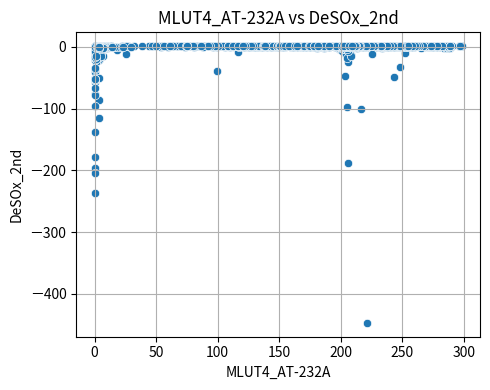

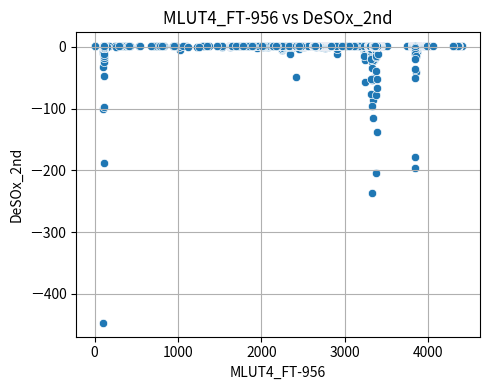

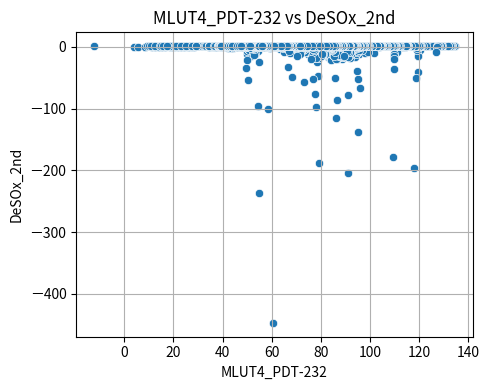

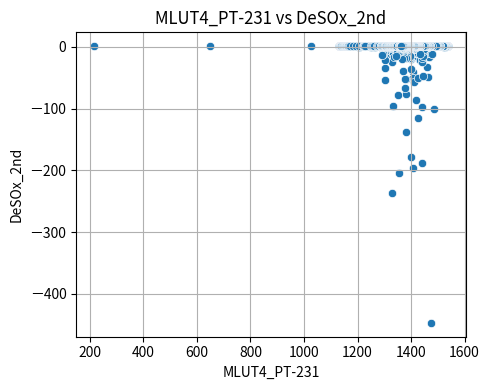

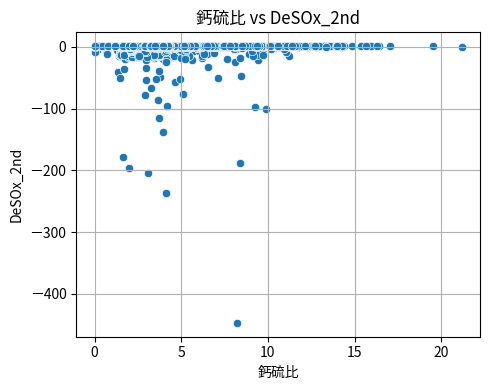

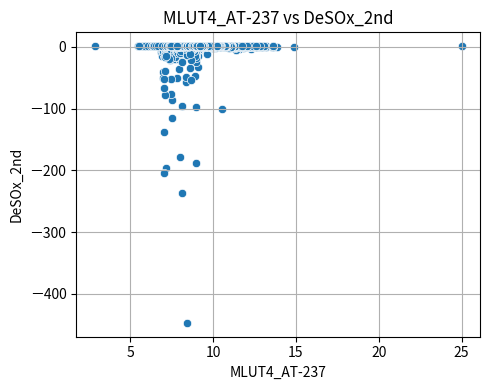

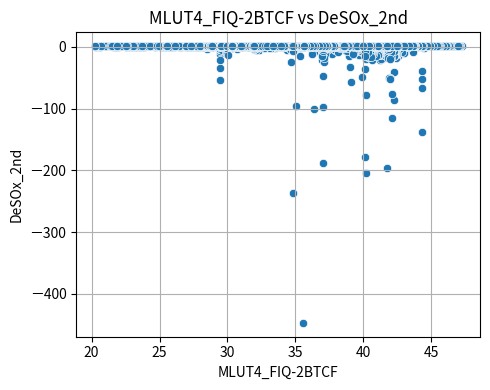

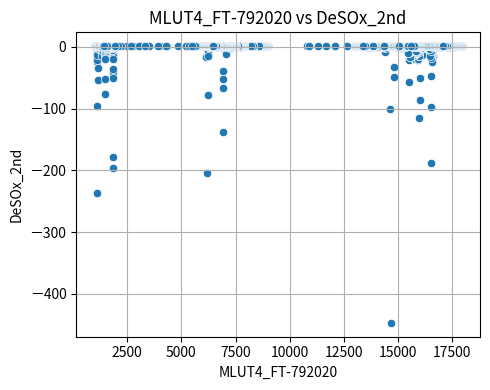

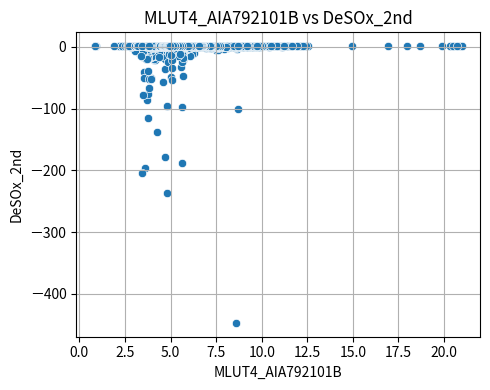

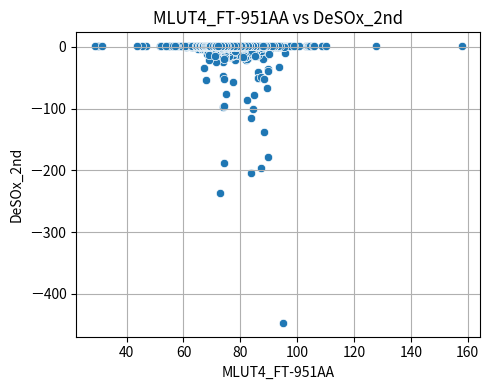

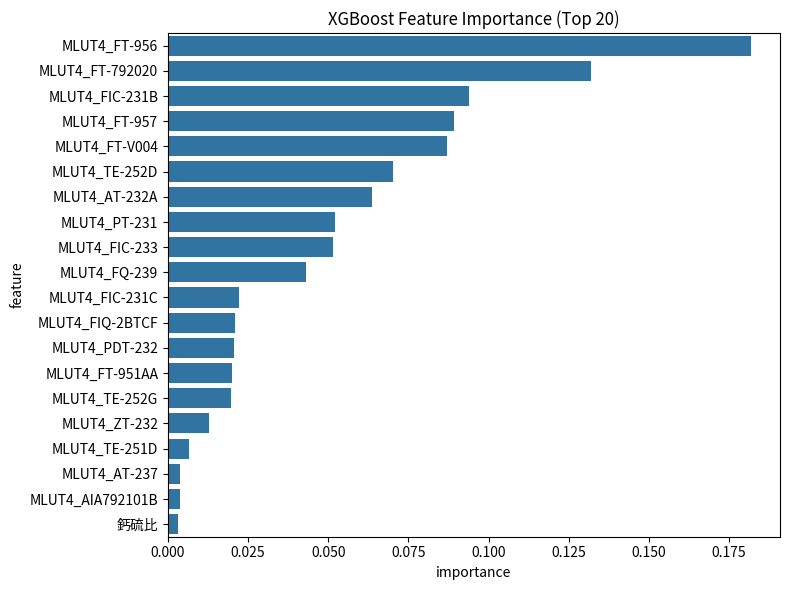

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 1. 檢查資料
df = select_df.copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=features + ['DeSOx_2nd'])

# 2. 計算皮爾森相關係數
correlations = {}
for col in features:
    corr = df[col].corr(df['DeSOx_2nd'])
    correlations[col] = corr

res_皮爾森 = pd.DataFrame.from_dict(correlations, orient='index', columns=['皮爾森相關係數'])
res_皮爾森 = res_皮爾森.sort_values(by='皮爾森相關係數', key=np.abs, ascending=False)

# 顯示皮爾森相關係數前 10
display(res_皮爾森.head(10))

# 3. 畫散點圖（前10個重要變數）
top10_features = res_皮爾森.head(10).index.tolist()
for feature in top10_features:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=df[feature], y=df['DeSOx_2nd'])
    plt.title(f'{feature} vs DeSOx_2nd')
    plt.xlabel(feature)
    plt.ylabel('DeSOx_2nd')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 4. 用 XGBoost 建模並顯示特徵重要度
X = df[features]
y = df['DeSOx_2nd']

# 分割資料
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立模型
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 特徵重要度可視化
importances = model.feature_importances_
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('XGBoost Feature Importance (Top 20)')
plt.tight_layout()
plt.show()
